In [13]:
from pathlib import Path
import sys

from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    if "IPython.extensions.autoreload" not in ip.extension_manager.loaded:
        ip.run_line_magic("load_ext", "autoreload")
    ip.run_line_magic("autoreload", "2")

project_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src" / "lif_utils.py").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import lif_utils as lu
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import time

In [5]:
CANVAS_HEIGHT = 128
CANVAS_WIDTH = 128
STEPS = 7

INTENSITY = 1.0

BLUR_KERNEL_LENGTH = 9
BLUR_SIGMA_ALONG = 1.3
BLUR_SIGMA_ACROSS = 0.1
BLUR_GAIN = 1.2

UPSTREAM_BETA = 0.90
UPSTREAM_THRESHOLD = 0.75

DOWNSTREAM_BETA = 0.80
DOWNSTREAM_THRESHOLD = 1.00

BUFFER_SIZE = 4
T_PLOT = 6

SHAPE_TEMPLATES = lu.make_toy_2d_shape_templates()

In [6]:
DIRECTION_CONFIG = {
    "right": {"velocity_y": 0, "velocity_x": 1, "start_top": 60, "start_left": 20},
    "left":  {"velocity_y": 0, "velocity_x": -1, "start_top": 60, "start_left": 103},
    "down":  {"velocity_y": 1, "velocity_x": 0, "start_top": 20, "start_left": 60},
    "up":    {"velocity_y": -1, "velocity_x": 0, "start_top": 103, "start_left": 60},
}

In [7]:
def make_constant_speed_membrane_case(
    speed,
    direction_name,
    shape_name="seven",
):
    """
    Clean case generator.

    Uses:
        - lu.make_moving_2d_shape
        - lu.apply_directional_blur_to_frames
        - lu.run_lif_2d_layer

    Does NOT use oracle metric code.
    """

    config = DIRECTION_CONFIG[direction_name]

    velocity_y = config["velocity_y"] * speed
    velocity_x = config["velocity_x"] * speed

    frames, origins = lu.make_moving_2d_shape(
        shape=SHAPE_TEMPLATES[shape_name],
        canvas_height=CANVAS_HEIGHT,
        canvas_width=CANVAS_WIDTH,
        steps=STEPS,
        start_top=config["start_top"],
        start_left=config["start_left"],
        velocity_y=velocity_y,
        velocity_x=velocity_x,
        intensity=INTENSITY,
    )

    input_current = lu.apply_directional_blur_to_frames(
        frames,
        velocity_y=velocity_y,
        velocity_x=velocity_x,
        kernel_length=BLUR_KERNEL_LENGTH,
        sigma_along=BLUR_SIGMA_ALONG,
        sigma_across=BLUR_SIGMA_ACROSS,
        gain=BLUR_GAIN,
    )

    upstream_spikes, upstream_membrane = lu.run_lif_2d_layer(
        input_current,
        beta=UPSTREAM_BETA,
        threshold=UPSTREAM_THRESHOLD,
    )

    return {
        "shape_name": shape_name,
        "direction_name": direction_name,
        "speed": speed,
        "velocity_y": velocity_y,
        "velocity_x": velocity_x,
        "frames": frames,
        "origins": origins,
        "input_current": input_current,
        "upstream_spikes": upstream_spikes,
        "upstream_membrane": upstream_membrane,
    }

In [8]:
def make_velocity_candidates(
    speeds=range(1, 21),
    directions=("right", "left", "down", "up"),
):
    candidates = []

    for speed in speeds:
        if "right" in directions:
            candidates.append({"direction": "right", "speed": speed, "velocity_y": 0, "velocity_x": speed})

        if "left" in directions:
            candidates.append({"direction": "left", "speed": speed, "velocity_y": 0, "velocity_x": -speed})

        if "down" in directions:
            candidates.append({"direction": "down", "speed": speed, "velocity_y": speed, "velocity_x": 0})

        if "up" in directions:
            candidates.append({"direction": "up", "speed": speed, "velocity_y": -speed, "velocity_x": 0})

    return candidates

In [9]:
def make_downstream_velocity_channel_inputs(
    upstream_membrane,
    candidates,
    t_plot=T_PLOT,
    buffer_size=BUFFER_SIZE,
):
    """
    Create downstream input streams for all candidate velocities.

    Output shape:
        [buffer_size, num_candidates, height, width]
    """

    all_time_inputs = []

    for lag in reversed(range(buffer_size)):
        source_t = t_plot - lag
        source_frame = upstream_membrane[source_t]

        candidate_inputs = []

        for candidate in candidates:
            shifted = lu.shift_2d_frame(
                source_frame,
                shift_y=lag * candidate["velocity_y"],
                shift_x=lag * candidate["velocity_x"],
            )

            candidate_inputs.append(torch.clamp(shifted, min=0))

        candidate_inputs = torch.stack(candidate_inputs, dim=0)
        all_time_inputs.append(candidate_inputs)

    return torch.stack(all_time_inputs, dim=0)

In [10]:
def run_downstream_velocity_lif_bank(
    input_stream,
    beta=DOWNSTREAM_BETA,
    threshold=DOWNSTREAM_THRESHOLD,
):
    """
    input_stream shape:
        [time, num_candidates, height, width]

    Returns:
        spikes:   [time, num_candidates, height, width]
        membrane: [time, num_candidates, height, width]
    """

    membrane = torch.zeros_like(input_stream[0])

    spike_record = []
    membrane_record = []

    for t in range(input_stream.shape[0]):
        membrane = beta * membrane + input_stream[t]

        spikes = (membrane >= threshold).float()

        # Subtractive reset
        membrane = membrane - spikes * threshold

        spike_record.append(spikes)
        membrane_record.append(membrane.clone())

    return torch.stack(spike_record), torch.stack(membrane_record)

In [11]:
def predict_speed_with_downstream_lif(
    upstream_membrane,
    candidate_speeds=range(1, 21),
    candidate_directions=("right", "left", "down", "up"),
    t_plot=T_PLOT,
    buffer_size=BUFFER_SIZE,
    downstream_beta=DOWNSTREAM_BETA,
    downstream_threshold=DOWNSTREAM_THRESHOLD,
):
    """
    Spike-only velocity prediction.

    No oracle.
    No target.
    No metric image comparison.
    """

    candidates = make_velocity_candidates(
        speeds=candidate_speeds,
        directions=candidate_directions,
    )

    input_stream = make_downstream_velocity_channel_inputs(
        upstream_membrane=upstream_membrane,
        candidates=candidates,
        t_plot=t_plot,
        buffer_size=buffer_size,
    )

    downstream_spikes, downstream_membrane = run_downstream_velocity_lif_bank(
        input_stream=input_stream,
        beta=downstream_beta,
        threshold=downstream_threshold,
    )

    final_spike_count = downstream_spikes[-1].flatten(start_dim=1).sum(dim=1)
    total_spike_count = downstream_spikes.flatten(start_dim=2).sum(dim=(0, 2))

    final_membrane = downstream_membrane[-1]
    final_membrane_sum = final_membrane.flatten(start_dim=1).sum(dim=1)
    final_membrane_max = final_membrane.flatten(start_dim=1).max(dim=1).values

    rows = []

    for i, candidate in enumerate(candidates):
        rows.append({
            "direction": candidate["direction"],
            "speed": candidate["speed"],
            "velocity_y": candidate["velocity_y"],
            "velocity_x": candidate["velocity_x"],
            "final_spike_count": final_spike_count[i].item(),
            "total_spike_count": total_spike_count[i].item(),
            "final_membrane_sum_diagnostic": final_membrane_sum[i].item(),
            "final_membrane_max_diagnostic": final_membrane_max[i].item(),
        })

    scores = pd.DataFrame(rows)

    # Final decision is spike-only.
    scores = scores.sort_values(
        ["final_spike_count", "total_spike_count"],
        ascending=False,
    ).reset_index(drop=True)

    return scores, {
        "candidates": candidates,
        "input_stream": input_stream,
        "downstream_spikes": downstream_spikes,
        "downstream_membrane": downstream_membrane,
    }

In [15]:
case = make_constant_speed_membrane_case(
    speed=6,
    direction_name="left",
    shape_name="seven",
)

start = time.time()

scores, channels = predict_speed_with_downstream_lif(
    upstream_membrane=case["upstream_membrane"],
    candidate_speeds=range(1, 21),
    candidate_directions=("right", "left", "down", "up"),
    downstream_beta=0.80,
    downstream_threshold=1.00,
)

elapsed = time.time() - start

print(f"Prediction runtime only: {elapsed:.4f} seconds")
scores.head(20)

Prediction runtime only: 0.0652 seconds


,direction,speed,velocity_y,velocity_x,final_spike_count,total_spike_count,final_membrane_sum_diagnostic,final_membrane_max_diagnostic
0,left,6,0,-6,6.0,7.0,78.634697,0.978761
1,left,12,0,-12,1.0,1.0,84.434708,0.962127
2,right,1,0,1,0.0,0.0,85.434708,0.832399
3,left,1,0,-1,0.0,0.0,85.434708,0.877682
4,down,1,1,0,0.0,0.0,85.434700,0.798616
5,up,1,-1,0,0.0,0.0,85.434700,0.820702
6,right,2,0,2,0.0,0.0,85.434700,0.777023
7,left,2,0,-2,0.0,0.0,85.434700,0.834402
8,down,2,2,0,0.0,0.0,85.434700,0.740052
9,up,2,-2,0,0.0,0.0,85.434700,0.763536


In [16]:
def test_all_directions_downstream_lif(
    speed=6,
    shape_name="seven",
    downstream_beta=0.80,
    downstream_threshold=1.00,
):
    rows = []

    for direction_name in ("right", "left", "down", "up"):
        case = make_constant_speed_membrane_case(
            speed=speed,
            direction_name=direction_name,
            shape_name=shape_name,
        )

        start = time.time()

        scores, channels = predict_speed_with_downstream_lif(
            upstream_membrane=case["upstream_membrane"],
            candidate_speeds=range(1, 21),
            candidate_directions=("right", "left", "down", "up"),
            downstream_beta=downstream_beta,
            downstream_threshold=downstream_threshold,
        )

        elapsed = time.time() - start
        best = scores.iloc[0]

        rows.append({
            "true_direction": direction_name,
            "true_speed": speed,
            "estimated_direction": best["direction"],
            "estimated_speed": best["speed"],
            "final_spike_count": best["final_spike_count"],
            "total_spike_count": best["total_spike_count"],
            "prediction_runtime_seconds": elapsed,
            "correct": (
                best["direction"] == direction_name
                and best["speed"] == speed
            ),
        })

    return pd.DataFrame(rows)

In [22]:
test_all_directions_downstream_lif(
    speed=6,
    shape_name="seven",
    downstream_beta=0.80,
    downstream_threshold=1.00,
)

,true_direction,true_speed,estimated_direction,estimated_speed,final_spike_count,total_spike_count,prediction_runtime_seconds,correct
0,right,6,right,6,6.0,7.0,0.052650,True
1,left,6,left,6,6.0,7.0,0.044141,True
2,down,6,down,6,34.0,67.0,0.057420,True
3,up,6,up,6,31.0,65.0,0.036083,True


In [27]:
def sweep_downstream_params_for_speed4(
    shape_name="seven",
    true_speed=4,
    true_directions=("right", "left", "down", "up"),
    downstream_betas=(0.60, 0.70, 0.80, 0.90, 0.95),
    downstream_thresholds=(0.40, 0.50, 0.60, 0.75, 0.90, 1.00, 1.25),
    candidate_speeds=range(1, 13),
    candidate_directions=("right", "left", "down", "up"),
):
    rows = []

    for true_direction in true_directions:
        config = DIRECTION_CONFIG[true_direction]

        velocity_y = config["velocity_y"] * true_speed
        velocity_x = config["velocity_x"] * true_speed

        frames, origins = lu.make_moving_2d_shape(
            shape=SHAPE_TEMPLATES[shape_name],
            canvas_height=CANVAS_HEIGHT,
            canvas_width=CANVAS_WIDTH,
            steps=STEPS,
            start_top=config["start_top"],
            start_left=config["start_left"],
            velocity_y=velocity_y,
            velocity_x=velocity_x,
            intensity=INTENSITY,
        )

        input_current = lu.apply_directional_blur_to_frames(
            frames,
            velocity_y=velocity_y,
            velocity_x=velocity_x,
            kernel_length=BLUR_KERNEL_LENGTH,
            sigma_along=BLUR_SIGMA_ALONG,
            sigma_across=BLUR_SIGMA_ACROSS,
            gain=BLUR_GAIN,
        )

        upstream_spikes, upstream_membrane = lu.run_lif_2d_layer(
            input_current,
            beta=UPSTREAM_BETA,
            threshold=UPSTREAM_THRESHOLD,
        )

        for beta in downstream_betas:
            for threshold in downstream_thresholds:
                scores, channels = predict_speed_with_downstream_lif(
                    upstream_membrane=upstream_membrane,
                    candidate_speeds=candidate_speeds,
                    candidate_directions=candidate_directions,
                    downstream_beta=beta,
                    downstream_threshold=threshold,
                )

                best = scores.iloc[0]

                rows.append({
                    "shape": shape_name,
                    "true_direction": true_direction,
                    "true_speed": true_speed,
                    "downstream_beta": beta,
                    "downstream_threshold": threshold,
                    "estimated_direction": best["direction"],
                    "estimated_speed": best["speed"],
                    "final_spike_count": best["final_spike_count"],
                    "total_spike_count": best["total_spike_count"],
                    "correct_direction": best["direction"] == true_direction,
                    "correct_speed": best["speed"] == true_speed,
                    "correct_exact": (
                        best["direction"] == true_direction
                        and best["speed"] == true_speed
                    ),
                    "absolute_speed_error": abs(best["speed"] - true_speed),
                })

    return pd.DataFrame(rows)

In [30]:
import time

start = time.time()

speed4_param_sweep = sweep_downstream_params_for_speed4(
    shape_name="seven",
    true_speed=4,
    true_directions=("right",),
    downstream_betas=(0.60, 0.70, 0.80, 0.90, 0.95),
    downstream_thresholds=(0.40, 0.50, 0.60, 0.75, 0.90, 1.00, 1.25),
    candidate_speeds=range(1, 13),
)

elapsed = time.time() - start
print(f"Speed-4 parameter sweep runtime: {elapsed:.4f} seconds")

speed4_param_sweep.head(10)

Speed-4 parameter sweep runtime: 0.8274 seconds


,shape,true_direction,true_speed,downstream_beta,downstream_threshold,estimated_direction,estimated_speed,final_spike_count,total_spike_count,correct_direction,correct_speed,correct_exact,absolute_speed_error
0,seven,right,4,0.6,0.40,right,2,59.0,164.0,True,False,False,2
1,seven,right,4,0.6,0.50,right,6,37.0,102.0,True,False,False,2
2,seven,right,4,0.6,0.60,right,5,26.0,60.0,True,False,False,1
3,seven,right,4,0.6,0.75,right,4,14.0,31.0,True,True,True,0
4,seven,right,4,0.6,0.90,right,4,8.0,20.0,True,True,True,0
5,seven,right,4,0.6,1.00,right,4,7.0,16.0,True,True,True,0
6,seven,right,4,0.6,1.25,right,4,3.0,7.0,True,True,True,0
7,seven,right,4,0.7,0.40,right,2,67.0,181.0,True,False,False,2
8,seven,right,4,0.7,0.50,right,4,51.0,130.0,True,True,True,0
9,seven,right,4,0.7,0.60,right,2,40.0,84.0,True,False,False,2


In [ ]:
test_all_directions_downstream_lif(
    speed=2,
    shape_name="seven",
    downstream_beta=0.7,
    downstream_threshold=0.9,
)

,true_direction,true_speed,estimated_direction,estimated_speed,final_spike_count,total_spike_count,prediction_runtime_seconds,correct
0,right,2,right,5,20.0,43.0,0.045819,False
1,left,2,left,5,20.0,43.0,0.053447,False
2,down,2,down,2,13.0,33.0,0.024485,True
3,up,2,up,2,14.0,33.0,0.025810,True


In [53]:
def sweep_downstream_params_for_speeds_1_to_6(
    shape_name="seven",
    true_speeds=range(1, 7),
    true_directions=("right", "left", "down", "up"),
    downstream_betas=(0.60, 0.70, 0.80, 0.90, 0.95),
    downstream_thresholds=(0.40, 0.50, 0.60, 0.75, 0.90, 1.00, 1.25),
    candidate_speeds=range(1, 13),
    candidate_directions=("right", "left", "down", "up"),
):
    rows = []

    for true_speed in true_speeds:
        for true_direction in true_directions:
            config = DIRECTION_CONFIG[true_direction]

            velocity_y = config["velocity_y"] * true_speed
            velocity_x = config["velocity_x"] * true_speed

            frames, origins = lu.make_moving_2d_shape(
                shape=SHAPE_TEMPLATES[shape_name],
                canvas_height=CANVAS_HEIGHT,
                canvas_width=CANVAS_WIDTH,
                steps=STEPS,
                start_top=config["start_top"],
                start_left=config["start_left"],
                velocity_y=velocity_y,
                velocity_x=velocity_x,
                intensity=INTENSITY,
            )

            input_current = lu.apply_directional_blur_to_frames(
                frames,
                velocity_y=velocity_y,
                velocity_x=velocity_x,
                kernel_length=BLUR_KERNEL_LENGTH,
                sigma_along=BLUR_SIGMA_ALONG,
                sigma_across=BLUR_SIGMA_ACROSS,
                gain=BLUR_GAIN,
            )

            upstream_spikes, upstream_membrane = lu.run_lif_2d_layer(
                input_current,
                beta=UPSTREAM_BETA,
                threshold=UPSTREAM_THRESHOLD,
            )

            for beta in downstream_betas:
                for threshold in downstream_thresholds:
                    scores, channels = predict_speed_with_downstream_lif(
                        upstream_membrane=upstream_membrane,
                        candidate_speeds=candidate_speeds,
                        candidate_directions=candidate_directions,
                        downstream_beta=beta,
                        downstream_threshold=threshold,
                    )

                    best = scores.iloc[0]

                    rows.append({
                        "shape": shape_name,
                        "true_direction": true_direction,
                        "true_speed": true_speed,
                        "downstream_beta": beta,
                        "downstream_threshold": threshold,
                        "estimated_direction": best["direction"],
                        "estimated_speed": best["speed"],
                        "final_spike_count": best["final_spike_count"],
                        "total_spike_count": best["total_spike_count"],
                        "correct_direction": best["direction"] == true_direction,
                        "correct_speed": best["speed"] == true_speed,
                        "correct_exact": (
                            best["direction"] == true_direction
                            and best["speed"] == true_speed
                        ),
                        "absolute_speed_error": abs(best["speed"] - true_speed),
                    })

    return pd.DataFrame(rows)

In [ ]:
import time

start = time.time()

speed1_to_6_param_sweep = sweep_downstream_params_for_speeds_1_to_6(
    shape_name="seven",
    true_speeds=range(1, 7),
    true_directions=("right", "left", "down", "up"),
    downstream_betas=(0.60, 0.70, 0.80, 0.90, 0.95),
    downstream_thresholds=(0.40, 0.50, 0.60, 0.75, 0.90, 1.00, 1.25),
    candidate_speeds=range(1, 13),
)

elapsed = time.time() - start
print(f"Speed 1–6 parameter sweep runtime: {elapsed:.4f} seconds")

speed1_to_6_param_sweep.head()

Speed 1–6 parameter sweep runtime: 12.4520 seconds


,shape,true_direction,true_speed,downstream_beta,downstream_threshold,estimated_direction,estimated_speed,final_spike_count,total_spike_count,correct_direction,correct_speed,correct_exact,absolute_speed_error
0,seven,right,1,0.6,0.40,left,2,33.0,106.0,False,False,False,1
1,seven,right,1,0.6,0.50,right,1,30.0,81.0,True,True,True,0
2,seven,right,1,0.6,0.60,right,1,22.0,70.0,True,True,True,0
3,seven,right,1,0.6,0.75,left,1,15.0,35.0,False,True,False,0
4,seven,right,1,0.6,0.90,right,2,14.0,25.0,True,False,False,1


In [55]:
speed1_to_6_param_summary = (
    speed1_to_6_param_sweep
    .groupby(["downstream_beta", "downstream_threshold"])
    .agg(
        exact_accuracy=("correct_exact", "mean"),
        direction_accuracy=("correct_direction", "mean"),
        mean_absolute_speed_error=("absolute_speed_error", "mean"),
        mean_final_spikes=("final_spike_count", "mean"),
        mean_total_spikes=("total_spike_count", "mean"),
        num_cases=("correct_exact", "count"),
    )
    .reset_index()
    .sort_values(
        ["exact_accuracy", "direction_accuracy", "mean_absolute_speed_error"],
        ascending=[False, False, True],
    )
)

speed1_to_6_param_summary

,downstream_beta,downstream_threshold,exact_accuracy,direction_accuracy,mean_absolute_speed_error,mean_final_spikes,mean_total_spikes,num_cases
11,0.70,0.90,0.916667,1.000000,0.250000,18.291667,36.875000,24
10,0.70,0.75,0.875000,1.000000,0.333333,26.166667,60.666667,24
19,0.80,1.00,0.750000,1.000000,0.666667,20.125000,36.083333,24
2,0.60,0.60,0.750000,0.916667,0.250000,31.583333,83.708333,24
5,0.60,1.00,0.750000,0.916667,0.833333,8.750000,18.458333,24
33,0.95,1.00,0.666667,0.958333,0.500000,30.250000,57.583333,24
9,0.70,0.60,0.666667,0.958333,0.541667,38.166667,101.166667,24
25,0.90,0.90,0.666667,0.875000,0.458333,31.416667,63.791667,24
34,0.95,1.25,0.625000,0.958333,0.750000,22.250000,33.041667,24
3,0.60,0.75,0.625000,0.875000,0.333333,20.791667,44.208333,24


In [82]:
def make_constant_speed_case(
    speed,
    direction_name,
    shape_name="seven",
):
    """
    Clean generator for a moving-shape LIF membrane case.

    No oracle.
    No target image.
    No metric scoring.
    Just:
        moving shape -> directional blur -> upstream LIF membrane/spikes
    """

    config = DIRECTION_CONFIG[direction_name]

    velocity_y = config["velocity_y"] * speed
    velocity_x = config["velocity_x"] * speed

    frames, origins = lu.make_moving_2d_shape(
        shape=SHAPE_TEMPLATES[shape_name],
        canvas_height=CANVAS_HEIGHT,
        canvas_width=CANVAS_WIDTH,
        steps=STEPS,
        start_top=config["start_top"],
        start_left=config["start_left"],
        velocity_y=velocity_y,
        velocity_x=velocity_x,
        intensity=INTENSITY,
    )

    input_current = lu.apply_directional_blur_to_frames(
        frames,
        velocity_y=velocity_y,
        velocity_x=velocity_x,
        kernel_length=BLUR_KERNEL_LENGTH,
        sigma_along=BLUR_SIGMA_ALONG,
        sigma_across=BLUR_SIGMA_ACROSS,
        gain=BLUR_GAIN,
    )

    upstream_spikes, upstream_membrane = lu.run_lif_2d_layer(
        input_current,
        beta=UPSTREAM_BETA,
        threshold=UPSTREAM_THRESHOLD,
    )

    return {
        "shape_name": shape_name,
        "direction_name": direction_name,
        "speed": speed,
        "velocity_y": velocity_y,
        "velocity_x": velocity_x,
        "frames": frames,
        "origins": origins,
        "input_current": input_current,
        "upstream_spikes": upstream_spikes,
        "upstream_membrane": upstream_membrane,
    }

In [104]:
test_all_directions_downstream_lif(
    speed=2,
    shape_name="seven",
    downstream_beta=0.7,
    downstream_threshold=0.9,
)

,true_direction,true_speed,estimated_direction,estimated_speed,final_spike_count,total_spike_count,prediction_runtime_seconds,correct
0,right,2,right,5,20.0,43.0,0.105948,False
1,left,2,left,5,20.0,43.0,0.059917,False
2,down,2,down,2,13.0,33.0,0.047128,True
3,up,2,up,2,14.0,33.0,0.041942,True


In [119]:
case = make_constant_speed_case(
    speed=2,
    direction_name="right",
    shape_name="seven",
)

scores, channels = predict_speed_with_downstream_lif(
    upstream_membrane=case["upstream_membrane"],
    candidate_speeds=range(1, 13),
    candidate_directions=("right", "left", "down", "up"),
    downstream_beta=0.70,
    downstream_threshold=0.90,
)

scores.head(20)

,direction,speed,velocity_y,velocity_x,final_spike_count,total_spike_count,final_membrane_sum_diagnostic,final_membrane_max_diagnostic
0,right,5,0,5,20.0,43.0,44.402805,0.828312
1,left,2,0,-2,20.0,41.0,45.662804,0.892112
2,right,4,0,4,19.0,50.0,41.207802,0.849939
3,left,1,0,-1,18.0,50.0,40.343803,0.891639
4,right,2,0,2,17.0,57.0,38.093803,0.863105
5,right,1,0,1,15.0,52.0,40.838802,0.886831
6,right,3,0,3,14.0,44.0,45.959805,0.896136
7,right,6,0,6,14.0,21.0,60.071800,0.882688
8,down,1,1,0,13.0,38.0,49.631802,0.891116
9,up,1,-1,0,13.0,37.0,49.883804,0.892114


In [120]:
candidate_keys_to_plot = [
    ("right", 5),
    ("right", 2),
    ("left", 2),
]

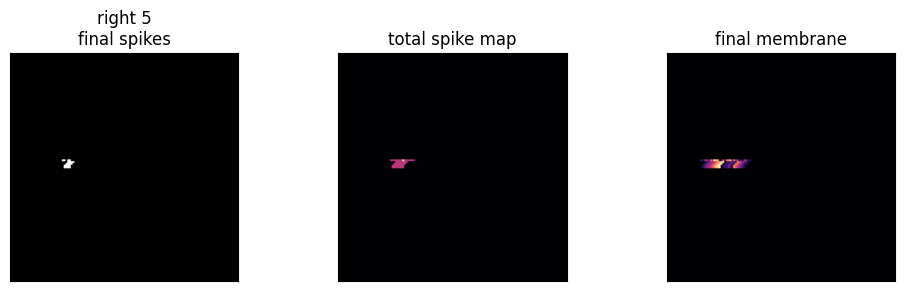

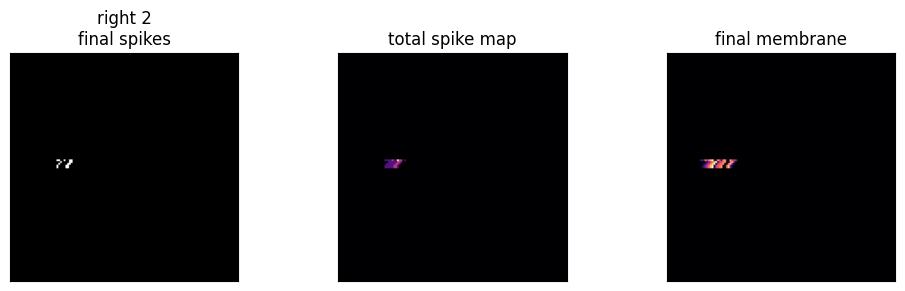

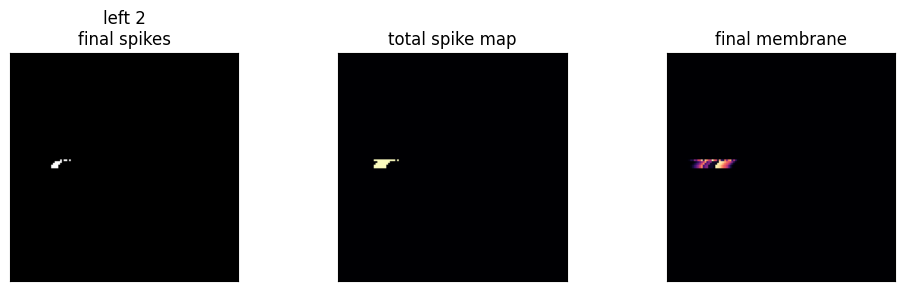

In [121]:
for direction, speed in candidate_keys_to_plot:
    candidate_index = None

    for i, c in enumerate(channels["candidates"]):
        if c["direction"] == direction and c["speed"] == speed:
            candidate_index = i
            break

    if candidate_index is None:
        print("Could not find", direction, speed)
        continue

    final_spikes = channels["downstream_spikes"][-1, candidate_index]
    total_spikes = channels["downstream_spikes"][:, candidate_index].sum(dim=0)
    final_membrane = channels["downstream_membrane"][-1, candidate_index]

    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    axes[0].imshow(final_spikes, cmap="gray")
    axes[0].set_title(f"{direction} {speed}\nfinal spikes")

    axes[1].imshow(total_spikes, cmap="magma")
    axes[1].set_title("total spike map")

    axes[2].imshow(final_membrane, cmap="magma")
    axes[2].set_title("final membrane")

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()